# Brute force Metropolis VMC simulation

## Analytic local energy

Results for N = 1, d = 3:
Minimum energy: 1.49
Minimum alpha: 0.52

Results for N = 10, d = 3:
Minimum energy: 14.97
Minimum alpha: 0.53

Results for N = 100, d = 3:
Minimum energy: 145.53
Minimum alpha: 0.45

Results for N = 500, d = 3:
Minimum energy: 219.84
Minimum alpha: 0.13



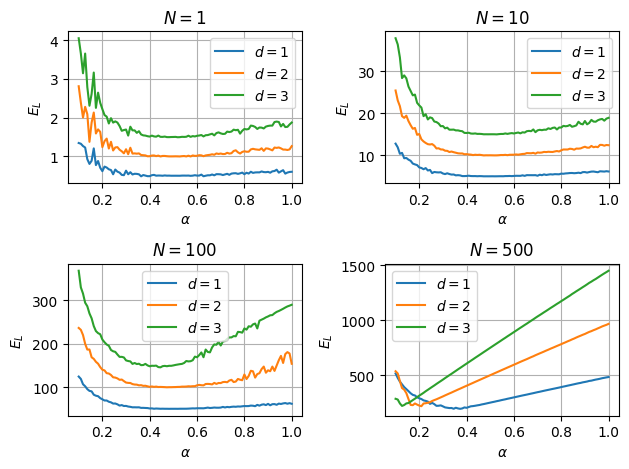

In [4]:
import matplotlib.pyplot as plt
import numpy as np

from vmc_jax import MetropolisJAX
from bose_harmonic import HarmonicParamGrid
from bose_harmonic_jax import wavefunction_jax, local_energy_jax, HarmonicParams

base_cycles = 10_000
base_step = 0.5

alpha_values = np.linspace(0.1, 1.0, 100)
param_grid = HarmonicParamGrid(param_type=HarmonicParams, alpha=alpha_values)

number_particles = [1, 10, 100, 500]
dims = [1, 2, 3]

fig, axs = plt.subplots(2, 2)
axs = axs.ravel()

for i, n in enumerate(number_particles):
  ax = axs[i]

  for j, d in enumerate(dims):
    #step_size = base_step / np.sqrt(n * d)
    #cycles = int(base_cycles * np.sqrt(n * d))

    simulation = MetropolisJAX[HarmonicParams](n, d)
    result = simulation.grid_search_brute(
      wavefunction_jax, local_energy_jax, param_grid, base_step, base_cycles
    )

    energies = result.energies
    ax.plot(alpha_values, energies, label=f"$d = {d}$")
    ax.set_title(f"$N = {n}$")
    ax.set(xlabel=r"$\alpha$", ylabel=r"$E_L$")
    ax.legend()
    ax.grid(True)

    if d == 3:
      min_energy = np.min(energies)
      min_alpha = alpha_values[np.argmin(energies)]
      print(f"Results for N = {n}, d = {d}:")
      print(f"Minimum energy: {min_energy:.2f}")
      print(f"Minimum alpha: {min_alpha:.2f}\n")

plt.tight_layout()
plt.show()


## Numerical local energy

AttributeError: 'GridSearchResult' object has no attribute 'energy'

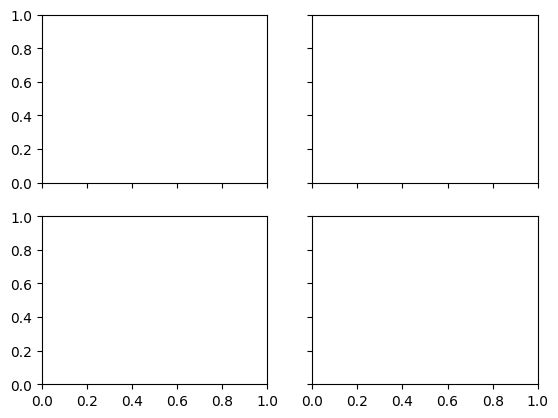

In [5]:
import matplotlib.pyplot as plt
import numpy as np

from vmc_jax import MetropolisJAX
from bose_harmonic import HarmonicParamGrid
from bose_harmonic_jax import wavefunction_jax, local_energy_numeric_jax, HarmonicParams

base_cycles = 10_000
base_step = 1.0

alpha_values = np.linspace(0.1, 1.0, 100)
param_grid = HarmonicParamGrid(param_type=HarmonicParams, alpha=alpha_values)

number_particles = [1, 10, 100, 500]
dims = [1, 2, 3]

fig, axs = plt.subplots(2, 2, sharex=True, sharey=True)
axs = axs.ravel()

for i, n in enumerate(number_particles):
  ax = axs[i]

  for j, d in enumerate(dims):
    step_size = base_step / np.sqrt(n * d)
    # cycles = int(base_cycles * np.sqrt(n * d))

    simulation = MetropolisJAX[HarmonicParams](n, d)
    results = simulation.grid_search_brute(
      wavefunction_jax, local_energy_numeric_jax, param_grid, step_size, base_cycles
    )
    energies = results.energy
    ax.plot(alpha_values, energies / n, label=f"$d = {d}$")
    ax.set_title(f"$N = {n}$")
    ax.set(xlabel=r"$\alpha$", ylabel=r"$E_L /N$")
    ax.legend()
    ax.grid(True)

    if d == 3:
      min_energy = np.min(energies)
      min_alpha = alpha_values[np.argmin(energies)]
      print(f"Results for N = {n}, d = {d}:")
      print(f"Minimum energy: {min_energy:.2f}")
      print(f"Minimum alpha: {min_alpha:.2f}\n")

plt.tight_layout()
plt.show()

## Comparison of analytic and numerical approach

Analytic time: 1.77 s
Numeric time: 24.52 s
Analytic is 13.87x faster


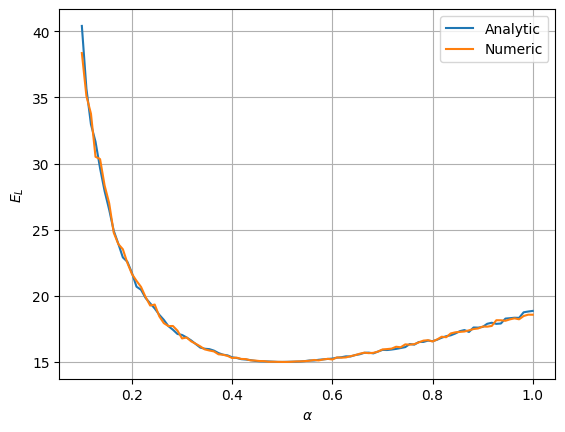

In [ ]:
import time

from matplotlib import pyplot as plt
import numpy as np

from vmc import Metropolis
from bose_harmonic import (
  wavefunction,
  local_energy,
  local_energy_numeric,
  HarmonicParams,
  HarmonicParamGrid,
)

cycles = 10_000
step_size = 1.0

alpha_values = np.linspace(0.1, 1.0, 100)
param_grid = HarmonicParamGrid(param_type=HarmonicParams, alpha=alpha_values)

number_particles = 10
dim = 3

# Analytic
simulation = Metropolis[HarmonicParams](number_particles, dim)

start_analytic = time.perf_counter()
result_analytic = simulation.grid_search_brute(
  wavefunction, local_energy, param_grid, step_size, cycles
)
stop_analytic = time.perf_counter()
time_analytic = stop_analytic - start_analytic

# Numeric
simulation_numeric = Metropolis[HarmonicParams](number_particles, dim)
start_numeric = time.perf_counter()
result_numeric = simulation.grid_search_brute(
  wavefunction, local_energy_numeric, param_grid, step_size, cycles
)
stop_numeric = time.perf_counter()
time_numeric = stop_numeric - start_numeric

print(f"Analytic time: {time_analytic:.2f} s")
print(f"Numeric time: {time_numeric:.2f} s")
if time_analytic < time_numeric:
  factor = time_numeric / time_analytic
  print(f"Analytic is {factor:.2f}x faster")
else:
  factor = time_analytic / time_numeric
  print(f"Numeric is {factor:.2f}x faster")

plt.plot(alpha_values, result_analytic.energy, label="Analytic")
plt.plot(alpha_values, result_numeric.energy, label="Numeric")
plt.xlabel(r"$\alpha$")
plt.ylabel(r"$E_L$")
plt.legend()
plt.grid(True)
plt.show()